# Example notebook: pipeline walkthrough with jaxtronomy

This notebook mirrors [`pipeline_walkthrough.ipynb`](pipeline_walkthrough.ipynb) but routes ray-shooting through [jaxtronomy](https://github.com/lenstronomy/JAXtronomy), the JAX backend for lenstronomy. The final section benchmarks `LensModel.ray_shooting` for three backends (lenstronomy/NumPy, jaxtronomy on CPU, jaxtronomy on GPU) for both a smooth lens and a lens with substructure (subhalos + line-of-sight halos).

Requires `mejiro[jax-cpu]` (CPU-only host) or `mejiro[jax-gpu]` (CUDA-12 host) plus `mejiro[roman]` for PSFs and exposures.

In [1]:
import os

# Select the JAX backend BEFORE jax is imported anywhere. Once jax is imported
# the platform is locked for the lifetime of the process.
os.environ.setdefault('JAX_PLATFORM_NAME', 'gpu')  # set to 'gpu' on a CUDA host

'cpu'

In [2]:
os.environ['JAX_PLATFORM_NAME'] = 'gpu'

In [3]:
!echo $JAX_PLATFORM_NAME

gpu


In [4]:
import json
import pickle
import subprocess
import sys
import tempfile
from copy import deepcopy
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
from pyHalo.preset_models import preset_model_from_name

import jax
from jaxtronomy.LensModel.profile_list_base import _JAXXED_MODELS

from mejiro.engines.galsim_engine import GalSimEngine
from mejiro.engines.stpsf_engine import STPSFEngine
from mejiro.exposure import Exposure
from mejiro.galaxy_galaxy import SampleGG, Sample1, Sample2
from mejiro.instruments.roman import Roman
from mejiro.synthetic_image import SyntheticImage
from mejiro.utils import lenstronomy_util

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [5]:
print('JAX version :', jax.__version__)
print('JAX backend :', jax.default_backend())
print('JAX devices :', jax.devices())

JAX version : 0.8.1
JAX backend : gpu
JAX devices : [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2)]


W0529 10:18:15.885795 3343593 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0529 10:18:15.887914 3343591 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0529 10:18:15.889966 3343592 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0529 10:18:15.894210 3343355 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0529 10:18:15.895098 3343355 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0529 10:18:15.896440 3343355 cuda_executor.cc:1802] GPU int

## Set up a strong lens

Identical to the standard walkthrough: `SampleGG()` constructs a Roman-like Galaxy-Galaxy lens with a SIE+SHEAR+CONVERGENCE macromodel, a SERSIC_ELLIPSE lens-light component, and a SERSIC_ELLIPSE source. The only difference is the explicit `use_jax` flag.

In [6]:
strong_lens = Sample1()

# `use_jax` is a per-profile list of bools. Setting all True routes every
# macromodel profile through jaxtronomy (subject to lenstronomy's _JAXXED_MODELS
# allowlist; profiles not in the list silently stay on NumPy).
strong_lens.use_jax = [True] * len(strong_lens.lens_model_list)
print('lens_model_list :', strong_lens.lens_model_list)
print('use_jax         :', strong_lens.use_jax)

lens_model_list : ['NFW_ELLIPSE_CSE', 'HERNQUIST_ELLIPSE_CSE', 'SHEAR', 'CONVERGENCE']
use_jax         : [True, True, True, True]


In [7]:
pprint(strong_lens.kwargs_model)

{'cosmo': FlatLambdaCDM(name='Planck18',
                        H0=<Quantity 67.66 km / (Mpc s)>,
                        Om0=0.30966,
                        Tcmb0=<Quantity 2.7255 K>,
                        Neff=3.046,
                        m_nu=<Quantity [0.  , 0.  , 0.06] eV>,
                        Ob0=0.04897),
 'lens_light_model_list': ['HERNQUIST_ELLIPSE'],
 'lens_model_list': ['NFW_ELLIPSE_CSE',
                     'HERNQUIST_ELLIPSE_CSE',
                     'SHEAR',
                     'CONVERGENCE'],
 'lens_redshift_list': [0.4089999999999997,
                        0.4089999999999997,
                        0.4089999999999997,
                        0.4089999999999997],
 'point_source_model_list': [],
 'source_light_model_list': ['INTERPOL'],
 'source_redshift_list': [1.0504635536161229],
 'z_source': 1.0504635536161229}


In [8]:
pprint(strong_lens.kwargs_params)

{'kwargs_lens': [{'Rs': 12.009805809840927,
                  'alpha_Rs': 2.152274160968798,
                  'center_x': 0.05492674339498643,
                  'center_y': -0.011555025525515692,
                  'e1': 0.09811990428304755,
                  'e2': 0.20670368492980223},
                 {'Rs': 0.5321226122963442,
                  'center_x': 0.05492674339498643,
                  'center_y': -0.011555025525515692,
                  'e1': 0.23256069438280758,
                  'e2': 0.31725006496727354,
                  'sigma0': 1.776219843615018},
                 {'dec_0': 0, 'gamma1': 0.0, 'gamma2': -0.0, 'ra_0': 0},
                 {'dec_0': 0, 'kappa': 0.0, 'ra_0': 0}],
 'kwargs_lens_light': [{'Rs': 0.5321226122963442,
                        'center_x': 0.05492674339498643,
                        'center_y': -0.011555025525515692,
                        'e1': 0.23256069438280758,
                        'e2': 0.31725006496727354,
                        'mag

## Add subhalos and line-of-sight halos with `pyHalo`

Unlike `pipeline_walkthrough.ipynb` (which sets `LOS_normalization=0.`), this notebook enables line-of-sight halos with `LOS_normalization=1.`. This is the physically motivated default for CDM and exercises the multi-plane code path that benefits most from jaxtronomy's GPU dispatch.

In [9]:
theta_e = strong_lens.get_einstein_radius()
CDM = preset_model_from_name('CDM')
realization = CDM(
    round(strong_lens.z_lens, 2),
    round(strong_lens.z_source, 2),
    sigma_sub=0.055,
    cone_opening_angle_arcsec=3 * theta_e,
    LOS_normalization=1.0,  # turn ON line-of-sight halos
    log_mlow=6.0,
    log_mhigh=10.0,
    log_m_host=13.4,
    r_tidal=0.5,
)
print(f'Generated realization with {len(realization.halos)} halos.')

Generated realization with 3724 halos.


In [10]:
# Keep a deep copy of the smooth lens for the benchmark and for visual comparison
strong_lens_smooth = deepcopy(strong_lens)

# add_realization auto-flips use_jax[i] to True for every halo profile in _JAXXED_MODELS;
# halos with profiles not in the allowlist (e.g. SPL_CORE) remain on NumPy.
strong_lens.add_realization(realization, use_jax=True)
print(f'lens_model_list now has {len(strong_lens.lens_model_list)} entries')

lens_model_list now has 3781 entries


In [11]:
# Report which halo profile types ended up on JAX vs NumPy.
from collections import Counter
profile_jax = Counter()
profile_numpy = Counter()
for name, on_jax in zip(strong_lens.lens_model_list, strong_lens.use_jax):
    (profile_jax if on_jax else profile_numpy)[name] += 1
print('On JAX  :', dict(profile_jax))
print('On NumPy:', dict(profile_numpy))

On JAX  : {'NFW_ELLIPSE_CSE': 1, 'HERNQUIST_ELLIPSE_CSE': 1, 'SHEAR': 1, 'CONVERGENCE': 54, 'TNFW': 3724}
On NumPy: {}


## Instrument and PSF

Same setup as the standard walkthrough: Roman WFI, F129 filter, STPSF-generated PSF at 5x oversampling.

In [12]:
roman = Roman()
instrument_params = roman.default_params()
kwargs_numerics = SyntheticImage.DEFAULT_KWARGS_NUMERICS

band = 'F129'
kernel = STPSFEngine.get_roman_psf(
    band=band,
    detector=instrument_params['detector'],
    detector_position=instrument_params['detector_position'],
    oversample=5,
    num_pix=101,
)
kwargs_psf = lenstronomy_util.get_pixel_psf_kwargs(kernel, supersampling_factor=5)

Generating PSF with STPSF, which may be slow. Consider caching frequently-used PSFs.


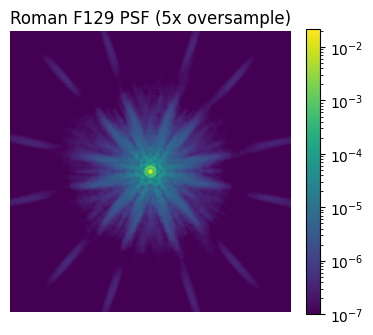

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(kernel, norm=plt.matplotlib.colors.LogNorm(vmin=1e-7))
ax.set_title(f'Roman {band} PSF (5x oversample)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## Produce the synthetic image

`SyntheticImage` calls `lenstronomy.ImageModel.image()`, which dispatches ray-shooting through whichever backend `strong_lens.lens_model` was built with. Because we set `use_jax=[True, ...]` above, the ray-shooting kernel runs through jaxtronomy.

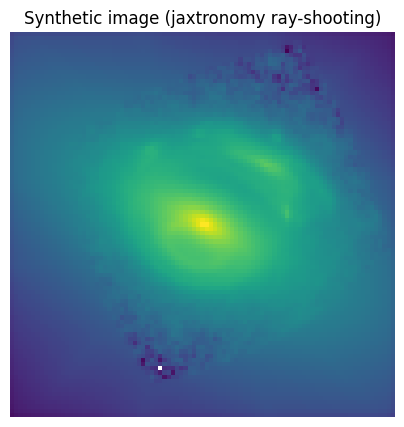

In [14]:
synthetic_image = SyntheticImage(
    strong_lens=strong_lens,
    instrument=roman,
    band=band,
    fov_arcsec=10,
    instrument_params=instrument_params,
    kwargs_numerics=kwargs_numerics,
    kwargs_psf=kwargs_psf,
    pieces=True,
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(synthetic_image.data, norm=plt.matplotlib.colors.LogNorm())
ax.set_title('Synthetic image (jaxtronomy ray-shooting)')
ax.axis('off')
plt.show()

In [15]:
# Sanity check: confirm jaxtronomy and lenstronomy agree on the deflection field.
# Use the smooth-lens version (fewer profiles, faster) and a coarse grid.
from lenstronomy.LensModel.lens_model import LensModel

_x = np.linspace(-2.5, 2.5, 60)
xx, yy = np.meshgrid(_x, _x)
x_flat, y_flat = xx.ravel(), yy.ravel()

lm_numpy = LensModel(strong_lens_smooth.lens_model_list, use_jax=[False] * len(strong_lens_smooth.lens_model_list))
lm_jax = LensModel(strong_lens_smooth.lens_model_list, use_jax=[True] * len(strong_lens_smooth.lens_model_list))

bx_np, by_np = lm_numpy.ray_shooting(x_flat, y_flat, strong_lens_smooth.kwargs_lens)
bx_jx, by_jx = lm_jax.ray_shooting(x_flat, y_flat, strong_lens_smooth.kwargs_lens)

max_abs_err = max(float(np.max(np.abs(np.asarray(bx_jx) - bx_np))),
                  float(np.max(np.abs(np.asarray(by_jx) - by_np))))
print(f'max |deflection_jax - deflection_numpy| = {max_abs_err:.3e}')
assert max_abs_err < 1e-5, 'jaxtronomy and lenstronomy disagree beyond tolerance!'
print('OK: jaxtronomy reproduces lenstronomy ray-shooting to within 1e-5.')

max |deflection_jax - deflection_numpy| = 4.441e-16
OK: jaxtronomy reproduces lenstronomy ray-shooting to within 1e-5.


## Benchmark: lenstronomy vs jaxtronomy-CPU vs jaxtronomy-GPU

We isolate the ray-shooting kernel (`LensModel.ray_shooting`) and time it for each backend over a 100×100 = 10 000-point grid, both for the smooth macromodel and for the macromodel + substructure + LOS halos.

Each backend runs in its own subprocess: JAX locks its platform on first import, so comparing CPU and GPU in the same kernel is not possible. The worker script [`_jax_benchmark_worker.py`](_jax_benchmark_worker.py) handles warmup (excluded from timings) and `jax.block_until_ready` (forces async GPU dispatch to complete before the clock stops).

**On a host without a GPU**, the `jax-gpu` subprocess is expected to fail; the bar is left empty with a 'GPU unavailable' annotation.

In [16]:
# Pickle the two lens variants to a tmpdir so each subprocess can load them.
tmpdir = tempfile.mkdtemp(prefix='jax_bench_')
smooth_path = os.path.join(tmpdir, 'lens_smooth.pkl')
substructure_path = os.path.join(tmpdir, 'lens_substructure.pkl')
with open(smooth_path, 'wb') as f:
    pickle.dump(strong_lens_smooth, f)
with open(substructure_path, 'wb') as f:
    pickle.dump(strong_lens, f)
print('Pickled lenses to', tmpdir)

Pickled lenses to /tmp/jax_bench_ceaore4r


In [17]:
WORKER = os.path.abspath('_jax_benchmark_worker.py')
BACKENDS = ['numpy', 'jax-cpu', 'jax-gpu']
LENSES = {'smooth': smooth_path, 'substructure': substructure_path}
PLATFORM = {'numpy': 'cpu', 'jax-cpu': 'cpu', 'jax-gpu': 'gpu'}

results = {label: {} for label in LENSES}
for label, path in LENSES.items():
    for backend in BACKENDS:
        env = {**os.environ, 'JAX_PLATFORM_NAME': PLATFORM[backend]}
        proc = subprocess.run(
            [sys.executable, WORKER,
             '--backend', backend,
             '--lens-pickle', path,
             '--n-warmup', '3',
             '--n-trials', '20',
             '--n-pix', '100'],
            env=env, capture_output=True, text=True,
        )
        if proc.returncode != 0:
            print(f'[skip] {label}/{backend}: {proc.stderr.strip().splitlines()[-1] if proc.stderr.strip() else "(no stderr)"}')
            results[label][backend] = None
        else:
            results[label][backend] = json.loads(proc.stdout.strip().splitlines()[-1])
            r = results[label][backend]
            print(f'{label:>13s} / {backend:<8s}: {r["mean_s"]*1e3:7.2f} +- {r["std_s"]*1e3:5.2f} ms')

       smooth / numpy   :    9.58 +-  0.06 ms
       smooth / jax-cpu :    2.07 +-  0.02 ms
       smooth / jax-gpu :    3.91 +-  2.02 ms
 substructure / numpy   : 1461.91 +-  8.60 ms
 substructure / jax-cpu :  509.58 +- 32.34 ms
 substructure / jax-gpu : 1268.74 +- 48.80 ms


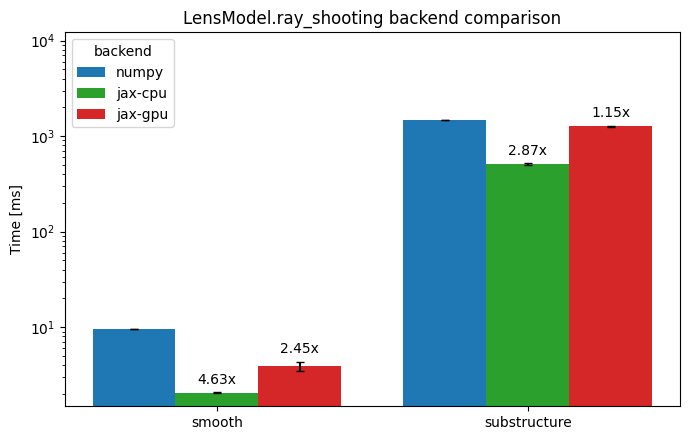

Speed-up relative to lenstronomy (numpy):
         smooth / jax-cpu :   4.63x
         smooth / jax-gpu :   2.45x
   substructure / jax-cpu :   2.87x
   substructure / jax-gpu :   1.15x


In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
lens_labels = list(LENSES.keys())
n_lenses = len(lens_labels)
n_backends = len(BACKENDS)
x_pos = np.arange(n_lenses)
bar_w = 0.8 / n_backends
colors = {'numpy': '#1f77b4', 'jax-cpu': '#2ca02c', 'jax-gpu': '#d62728'}

for i, backend in enumerate(BACKENDS):
    means, errs = [], []
    for label in lens_labels:
        r = results[label][backend]
        if r is None:
            means.append(np.nan); errs.append(0.0)
        else:
            means.append(r['mean_s'] * 1e3)
            errs.append(r['std_s'] / np.sqrt(r['n_trials']) * 1e3)
    offset = (i - (n_backends - 1) / 2) * bar_w
    bars = ax.bar(x_pos + offset, means, bar_w, yerr=errs, label=backend, color=colors[backend], capsize=3)
    for j, (m, e) in enumerate(zip(means, errs)):
        if np.isnan(m):
            ax.text(x_pos[j] + offset, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.01,
                    'unavailable', ha='center', va='bottom', rotation=90, color='gray')
        elif backend != 'numpy':
            base = results[lens_labels[j]].get('numpy')
            if base is not None:
                speedup = base['mean_s'] / (m / 1e3)
                ax.text(x_pos[j] + offset, (m + e) * 1.15, f'{speedup:.2f}x',
                        ha='center', va='bottom', rotation=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(lens_labels)
ax.set_yscale('log')
# leave headroom above the tallest bar so the speed-up labels clear the top spine
y0, y1 = ax.get_ylim()
ax.set_ylim(y0, y1 * 6)
ax.set_ylabel('Time [ms]')
ax.set_title(f'LensModel.ray_shooting backend comparison')  #  (JAX backend: {jax.default_backend()})
ax.legend(title='backend')
# ax.grid(True, axis='y', which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('ray_shooting_backend_comparison.png', dpi=300)
plt.show()

print('Speed-up relative to lenstronomy (numpy):')
for label in lens_labels:
    base = results[label].get('numpy')
    if base is None:
        print(f'  {label}: numpy baseline unavailable')
        continue
    for backend in ('jax-cpu', 'jax-gpu'):
        r = results[label].get(backend)
        if r is None:
            print(f'  {label:>13s} / {backend:<8s}: unavailable')
        else:
            print(f'  {label:>13s} / {backend:<8s}: {base["mean_s"] / r["mean_s"]:6.2f}x')

Timings exclude JIT warmup (3 untimed calls per backend); reported numbers are the steady-state per-call cost on a 100×100 grid. Expect jaxtronomy-CPU to beat lenstronomy-NumPy by ~2-3x on the smooth lens and more on the substructure lens; jaxtronomy-GPU should pull further ahead on the substructure case where the lens model list is long enough to amortize the host\u2194device transfer cost.